<a href="https://colab.research.google.com/github/wavejumper3/Machine-Learning-349/blob/main/HW1/Notebook_5_Python_ML_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Python and Machine Learning Workflows**


## A. GitHub Integration

To submit your work for grading, link your Colab instance directly to your repository:
1. Click **File** in the top left menu.
2. Select **Save** a copy in **GitHub**.
3. **Authorize** Google Colab to access your course repository.
4. Select your specific repository and branch to commit your notebook directly.



---
## B. Core Programming Paradigms in Machine Learning

* Python is a **multi-paradigm language**, meaning it supports **procedural**, **object-oriented**, and **functional** code.



* In Machine Learning pipelines, you will use a hybrid approach:

  *  **Object-Oriented**: Instantiating models and pipelines from libraries like **Scikit-Learn.**

  * **Functional / Declarative**: Applying math transformations swiftly across massive datasets without slow, explicit loops.

 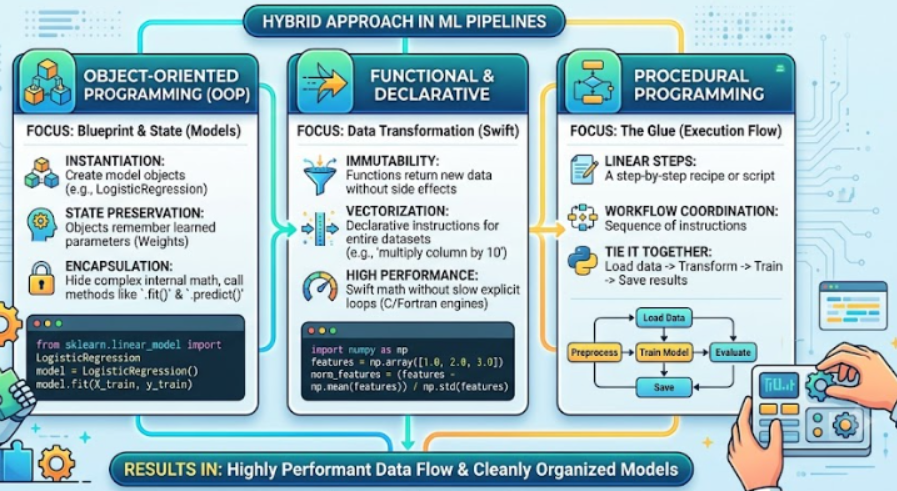





## C. Basic Data Types and Dynamic Typing

* Python is **case-sensitive** and **dynamically typed**.

* Variables are bound to objects at execution time, and their types can change freely based on what value is assigned to them.

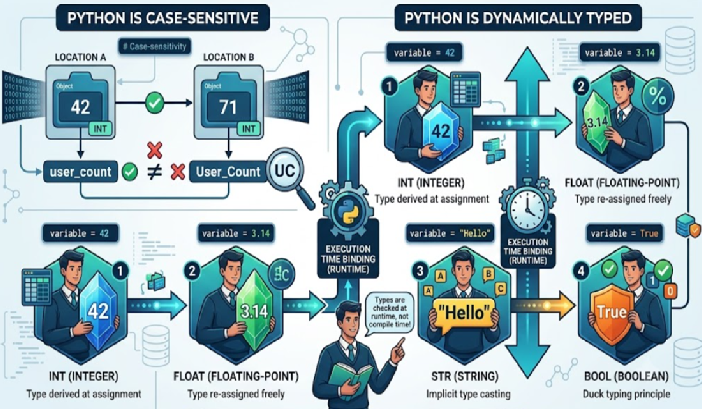



In [2]:
# Inspecting types dynamically
x = 100
print(f"Value: {x} | Type: {type(x)}")

# Reassigning to a floating-point number
x = 3.14159
print(f"Value: {x} | Type: {type(x)}")

# Reassigning to a string
x = "Scikit-Learn"
print(f"Value: {x} | Type: {type(x)}")

# Boolean types (Booleans evaluate to integers under the hood: True == 1, False == 0)
is_clipping = True
print(f"Value: {is_clipping} | Type: {type(is_clipping)}")
print(f"Is is_clipping exactly equal to 1? {is_clipping == 1}")

Value: 100 | Type: <class 'int'>
Value: 3.14159 | Type: <class 'float'>
Value: Scikit-Learn | Type: <class 'str'>
Value: True | Type: <class 'bool'>
Is is_clipping exactly equal to 1? True


---
## D. Functions, Control Flow, and Formatting

* Machine learning workflows require structured code blocks and clean log tracking.

* Python uses strictly **enforced indentation** (4 spaces) **instead of curly braces** to establish code **block scope**.


<br>

### 1. Functional Logic and String Formatting
* Use **f-strings** (formatted string literals) for readable logging during model training loops.

<br>

* **def log_training_metrics(epoch: int, loss: float, optimizer_name: str) -> None:**
  * **Type Hints**: The arguments are annotated with expected types (int, float, str).
  

  * **Return Type**: -> **None** explicitly indicates that this function executes actions (printing to the console) but does not return any data.


<br>

* **Type hints**

  *  **Not required** because Python's runtime is designed to dynamically execute your code regardless of types

  * A **highly recommended practice** because they act as "**live documentation**" that helps developer tools (like IDEs and static analyzers) catch bugs and provide auto-complete before your code ever runs.

In [3]:
def log_training_metrics(epoch: int, loss: float, optimizer_name: str) -> None:
    """Logs model metrics using clean block layout structures."""
    if loss < 0:
        print("Warning: Negative loss encountered. Checking dataset...")
        return

    # f-strings allow easy inline evaluations and float precision cropping (:03d, :.4f)
    print(f"Epoch {epoch:03d} | Optimizer: {optimizer_name:12s} | Loss: {loss:.4f}")

log_training_metrics(1, 0.453281, "Adam")
log_training_metrics(2, 0.120400, "SGD")

Epoch 001 | Optimizer: Adam         | Loss: 0.4533
Epoch 002 | Optimizer: SGD          | Loss: 0.1204


### 2. Range Boundaries


* The range(start, stop, step) function is exclusive of the stopping value.

* You do not always have to provide all three arguments:

  * start (Optional): Defaults to 0 if omitted.

  * step (Optional): Defaults to 1 if omitted. It dictates the increment (or decrement) between numbers.

<br>

 * Common examples & use cases:

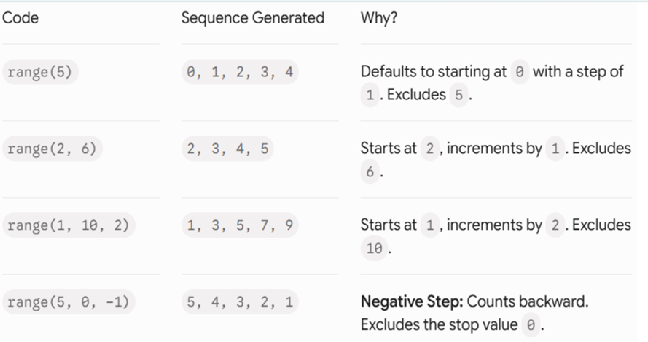



In [4]:
# Loops from -12 up to (but not including) 12 by steps of 4
for i in range(-12, 12, 4):
    print(i, end=" ")

-12 -8 -4 0 4 8 

---

## E. Dictionaries: Handling Model Hyperparameters

* **Hyperparameters** are the external configuration settings of a machine learning model—such as the learning rate, batch size, or number of trees—that you manually set before training begins to control and guide the learning process, unlike regular parameters which the model learns on its own during training.

* **Dictionaries** map keys to values and are the primary structure used to manage hyperparameters, dataset configurations, and training options in Machine Learning pipelines.

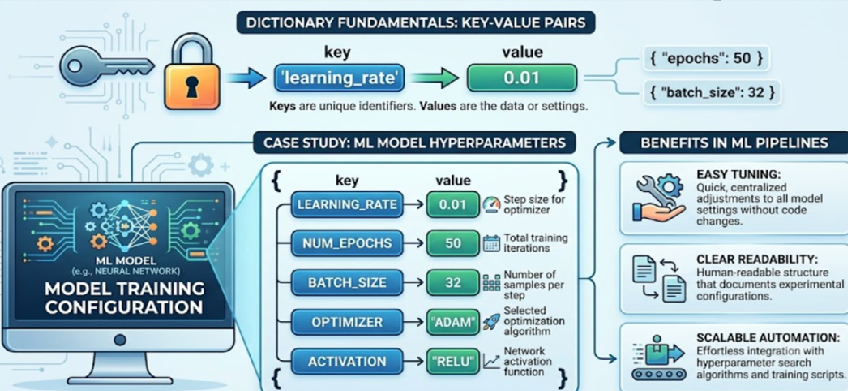

### 1. Instantiation and Evaluation
* Always use the native pythonic **in** operator to verify if a key exists.
* Do not use low-level dunder wrappers like **._contains_.**

In [5]:
# Dictionaries map configurations seamlessly
model_config = {
    "algorithm": "RandomForest",
    "n_estimators": 100,
    "max_depth": 5,
    "random_state": 42
}

# Pythonic membership testing using in
if "max_depth" in model_config:
    print(f"The tree depth threshold is set to: {model_config['max_depth']}")

The tree depth threshold is set to: 5


### 2. Inspecting and Manipulating Keys/Values

 * **.keys()**: Retrieves an iterable view of all the unique keys (the configuration names like "learning_rate", "batch_size") in the dictionary.

 * **.values()**: Retrieves an iterable view of all the corresponding data values associated with those keys.

* **sorted()**: Takes the dictionary's keys and returns a brand-new, alphabetically ordered list of those keys.

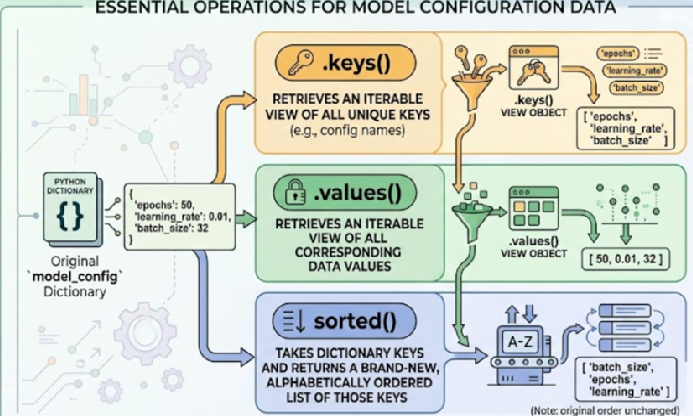



In [6]:
# View dictionary components
print("Keys:", list(model_config.keys()))
print("Values:", list(model_config.values()))

# Deleting a parameter
if "random_state" in model_config:
    del model_config["random_state"]

# Sorting configurations alphabetically by key
sorted_keys = sorted(model_config.keys())
print("Sorted Parameters:", sorted_keys)

Keys: ['algorithm', 'n_estimators', 'max_depth', 'random_state']
Values: ['RandomForest', 100, 5, 42]
Sorted Parameters: ['algorithm', 'max_depth', 'n_estimators']


---
## F. Sets: Tracking Unique Features

* Sets are native built-in collection primitives in Python 3.

* No import statements are required to use them.

* They enforce absolute uniqueness, which is highly useful for verifying feature columns or removing duplicate data fields.

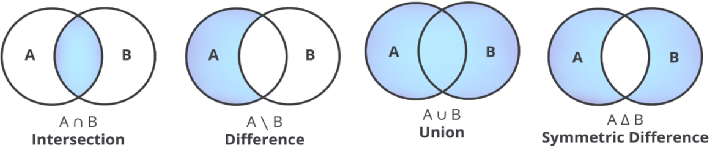


In [7]:
# Instantiate sets directly using literal braces or the set constructor
features_dataset_A = {'age', 'income', 'credit_score', 'zip_code'}
features_dataset_B = set(['credit_score', 'zip_code', 'default_risk', 'employment_years'])

# Finding mutual intersections
common_features = features_dataset_A.intersection(features_dataset_B)
print("Intersected Fields:", common_features)

# Combining distinct features
all_features = features_dataset_A.union(features_dataset_B)
print("All Unique Fields Across Datasets:", all_features)

# Isolating variance differences
unique_to_A = features_dataset_A.difference(features_dataset_B)
print("Unique to Dataset A:", unique_to_A)

Intersected Fields: {'credit_score', 'zip_code'}
All Unique Fields Across Datasets: {'default_risk', 'zip_code', 'income', 'credit_score', 'age', 'employment_years'}
Unique to Dataset A: {'income', 'age'}


---
## G. Lists

* **Lists** store ordered sequences of items.

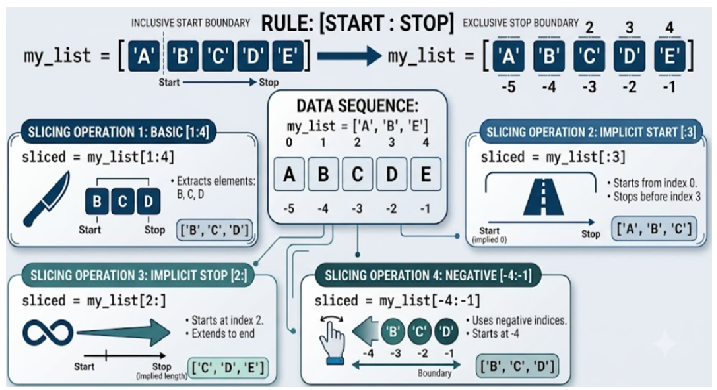<br>

* List **Slicing** ([start:stop])
  * Just like Python's range() function, **list slicing** is **inclusive of the start** index but **exclusive of the stop** index.

  * It **grabs elements at index 0, 1, and 2**, but **excludes index 3** ("KMeans").

<br>

* While numerical matrices use specialized arrays, native Python lists are perfect for managing string collections, model names, or pipeline steps.

<br>

 * **.append(item)**:
   * Adds the new element directly to the very end of the list.
   
   * This is an $O(1)$ constant-time operation..insert(index, item): Inserts the element at the specified index, shifting all subsequent elements to the right.
   
   * Here, "LogisticRegression" becomes the new index 1, shifting "SVM" to index 2.

<br>

 * **.insert(index, item)**:
   * Inserts the element at the specified index, shifting all subsequent elements to the right.
   
   * Here, "LogisticRegression" becomes the new index 1, shifting "SVM" to index 2.

<br>

* **.remove(item)**:

  * Searches the list from left to right and deletes the first occurrence of that value, shifting the remaining elements left to fill the gap.

In [8]:
ml_models = ["LinearRegression", "SVM", "DecisionTree", "KMeans"]

# Slicing syntax -> models[start:stop] (stop index is exclusive)
supervised_models = ml_models[0:3]
print("Sliced List:", supervised_models)

# Appending and inserting items dynamically
ml_models.append("XGBoost")
ml_models.insert(1, "LogisticRegression")
print("Expanded List:", ml_models)

# Modifying structural indexes safely
if "SVM" in ml_models:
    ml_models.remove("SVM")
print("Final List:", ml_models)

Sliced List: ['LinearRegression', 'SVM', 'DecisionTree']
Expanded List: ['LinearRegression', 'LogisticRegression', 'SVM', 'DecisionTree', 'KMeans', 'XGBoost']
Final List: ['LinearRegression', 'LogisticRegression', 'DecisionTree', 'KMeans', 'XGBoost']


### The ML Paradigm: List Comprehensions

* In modern data pipelines, structural transformations use **List Comprehensions** instead of older functional maps or filters.

<br>

* They are faster, cleaner, and highly readable.

<br>

* A **list comprehension squashes** a multi-line loop into a single, highly readable line of code. It consists of three primary components wrapped in square brackets:
<br>
   $$[\text{expression} \quad \text{for item in iterable} \quad \text{if condition}]$$

<br>

   1.  **Expression**: The operation or transformation applied to each element (e.g., squaring a number, casting a type).

   2. **Iteration**: The loop variable and the sequence being iterated over.

   3. **Filter** (Optional): A conditional clause that determines whether the element should be included in the final output.

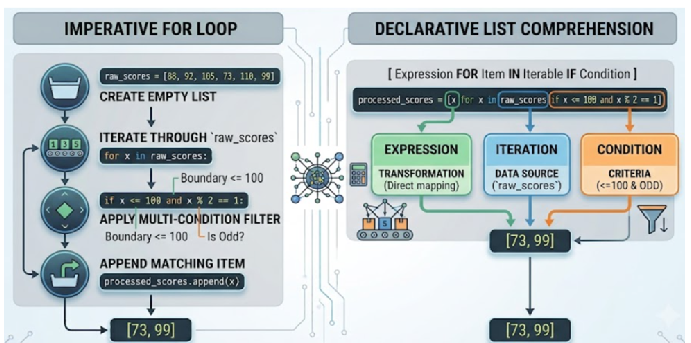



In [9]:
raw_scores = [88, 92, 105, 73, 110, 99]

# Goal: Filter out baseline anomalies (scores above 100) and preserve odd scores
# Pythonic List Comprehension syntax:
processed_scores = [x for x in raw_scores if x <= 100 and x % 2 == 1]
print("Filtered and Processed Scores:", processed_scores)

Filtered and Processed Scores: [73, 99]


---
## H. Consuming Classes and Object-Oriented Frameworks

* In Machine Learning applications, you will rarely write custom object classes from scratch.

* Instead, you will consume API objects provided by external frameworks like Scikit-Learn.

* Understanding how to initialize a class, execute its methods, and read its learned attributes is a core skill.

<br><br>

* **class**
   * **Underscores**

     * In standard Python, a **trailing underscore** is usually a workaround to avoid clashing with reserved keywords; e.g., **class_** or **type_**

     * However, in the Scikit-Learn framework, they repurposed this convention.
     
     * They use a single trailing underscore to signal "**Estimated/Learned Attributes**".

     * By naming them **coef_** and **intercept_**, we are specifying that these variables exist, but we shouldn't read them until the model has been trained via **.fit()**
     
     * It clearly distinguishes them from hyperparameters like **self.fit_intercept** which are set at the very beginning.


<br>

  * __init__ is a built-in "dunder" (double underscore) magic method.

     `model = LinearRegressionPlaceholder(fit_intercept=True)`
    *  Here, Python automatically looks for __init__ behind the scenes and executs it to set up your class variables.
    * To **train** the model, we call the **model.fit()** method with our data.

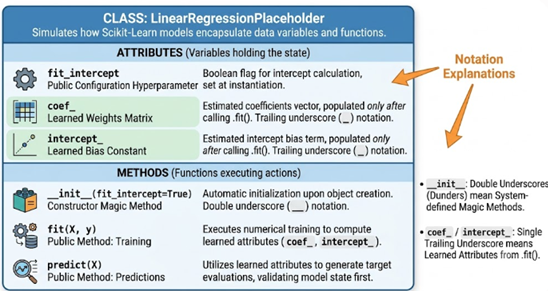

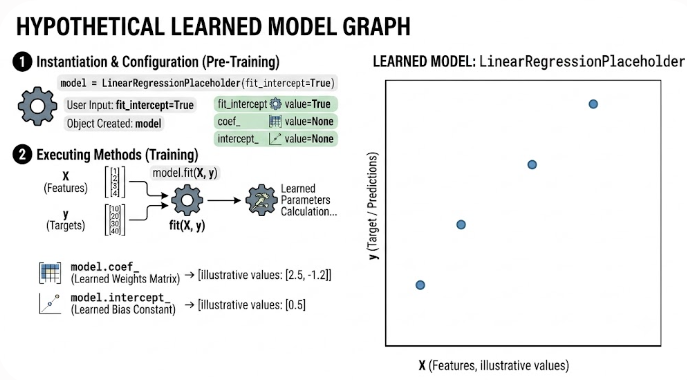

In [10]:
class LinearRegressionPlaceholder:
    """Simulates how Scikit-Learn models encapsulate data variables and functions."""

    def __init__(self, fit_intercept=True):
        # Public configuration configurations set during creation
        self.fit_intercept = fit_intercept

        # Trailing underscores indicate parameters learned *after* running training (.fit())
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        """A Public method executing internal numerical training calculations."""
        print("Training model variables against structural dataset targets...")
        # Simulating learned matrix parameters calculation
        self.coef_ = [2.54, -1.22]
        self.intercept_ = 0.44
        return self

    def predict(self, X):
        """A Public method utilizing learned attributes to return calculations."""
        if self.coef_ is None:
            raise ValueError("Model must be trained using .fit() before generating predictions.")
        print("Generating array evaluations...")
        return [1.0, 0.0]

# --- THE EXTRACTED ML INTERACTION API WORKFLOW ---

# 1. Initialization (Passing Hyperparameters)
model = LinearRegressionPlaceholder(fit_intercept=True)
print("Model Configuration Hyperparameter (fit_intercept):", model.fit_intercept)
print("Model Weights Before Training (.coef_):", model.coef_)

# 2. Executing Methods to train systems
# Fixed: Provided example numerical data for X and y
model.fit(X=[[1, 2], [3, 4]], y=[10, 20])

# 3. Reading Trailing Attribute Metadata computed by the object
print("Learned Weights Matrix (.coef_):", model.coef_)
print("Learned Bias Constants (.intercept_):", model.intercept_)

# 4. Generating Predictions
# Fixed: Provided example numerical data for X
predictions = model.predict(X=[[5, 6]])
print("Output Vector:", predictions)

Model Configuration Hyperparameter (fit_intercept): True
Model Weights Before Training (.coef_): None
Training model variables against structural dataset targets...
Learned Weights Matrix (.coef_): [2.54, -1.22]
Learned Bias Constants (.intercept_): 0.44
Generating array evaluations...
Output Vector: [1.0, 0.0]


---
## I. Moving Beyond Base Python: Vectorization

* Standard Python **loops and recursive calculations are incredibly slow** when running mathematical operations across datasets with millions of elements.

* For efficiency, Machine Learning shifts away from standard lists to **Vectorized Arrays** powered by **NumPy**.

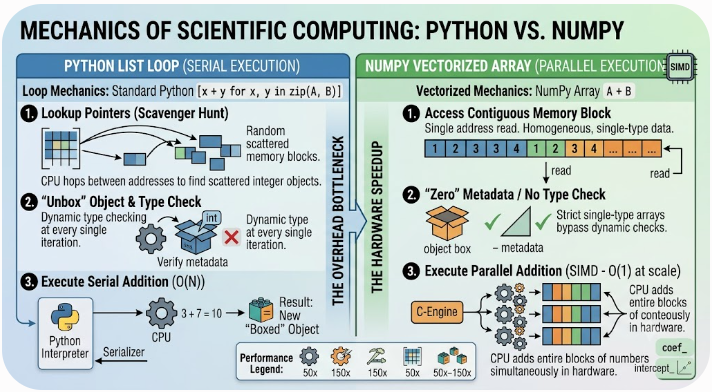

In [18]:
import numpy as np
import time

# Create a list and array with 1 million elements
size = 1_000_000
python_list_A = list(range(size))
python_list_B = list(range(size))

numpy_array_A = np.arange(size)
numpy_array_B = np.arange(size)

# --- TEST 1: Standard Python List Iteration ---
start_time = time.time()
loop_result = [x + y for x, y in zip(python_list_A, python_list_B)]
python_duration = time.time() - start_time
print(f"Python Loop Duration: {python_duration:.4f} seconds")

# --- TEST 2: Vectorized Matrix Addition ---
start_time = time.time()
vector_result = numpy_array_A + numpy_array_B  # Direct element-wise math execution without loops
numpy_duration = time.time() - start_time
print(f"NumPy Vectorized Duration: {numpy_duration:.4f} seconds")

# Performance Comparison Calculation
print(f"\nNumPy array operations ran {python_duration / numpy_duration:.1f}x faster!")

Python Loop Duration: 0.0506 seconds
NumPy Vectorized Duration: 0.0012 seconds

NumPy array operations ran 42.6x faster!


---
## J. Tabular Infrastructure: Introduction to Pandas DataFrames

* Real-world data science datasets do not arrive as tidy arrays or dictionaries.

* They are structured as tabular tables.

* Pandas is the foundational standard library used to load, clean, slice, and preprocess datasets before feeding them to Scikit-Learn models.

* We can identify missing values in rows, remove/add/modify and slice columns, etc.

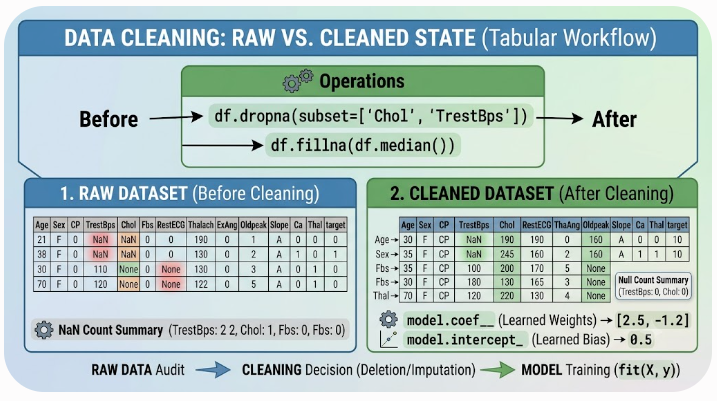

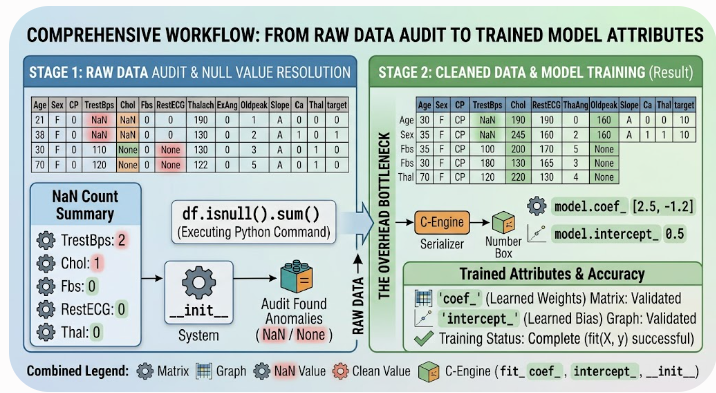

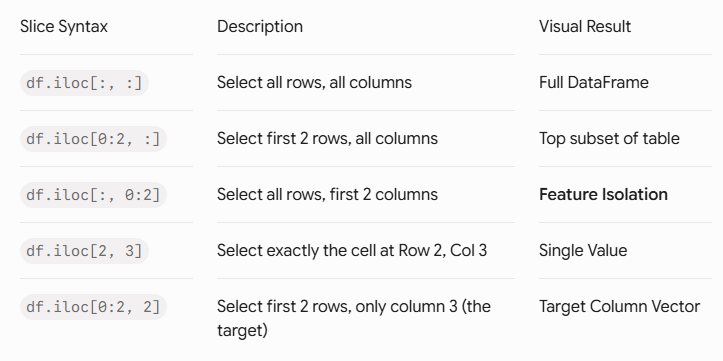

In [19]:
import pandas as pd

# Simulating a standard raw machine learning dataset with string classes and missing inputs (None/NaN)
raw_data = {
    "Size_sqft": [1500, 2100, None, 1850, 3200],
    "Bedrooms": [3, 4, 2, 3, 5],
    "Price_USD": [300000, 450000, 250000, 380000, 600000],
    "Neighborhood": ["Downtown", "Suburbs", "Downtown", "Suburbs", "Westside"]
}

# 1. Instantiating a DataFrame table structure
df = pd.DataFrame(raw_data)
print("--- 1. Initial Structural DataFrame Loaded ---")
print(df)

# 2. Managing Missing Value Anomalies (Crucial: Scikit-Learn models crash if passed NaN values)
print("\n--- 2. Checking for Null Missing Items ---")
print(df.isnull().sum())

# Clean the DataFrame dynamically by dropping rows with missing items
df_clean = df.dropna()
print("\n--- 3. Cleaned DataFrame (Missing Row Removed) ---")
print(df_clean)

# 4. Tabular Slicing: Isolating targets from feature attributes using index positions (.iloc)
# Syntax: df.iloc[row_slice, column_slice]
features_only = df_clean.iloc[:, 0:2]
print("\n--- 4. Feature Slices Extracted (.iloc Range) ---")
print(features_only)

--- 1. Initial Structural DataFrame Loaded ---
   Size_sqft  Bedrooms  Price_USD Neighborhood
0     1500.0         3     300000     Downtown
1     2100.0         4     450000      Suburbs
2        NaN         2     250000     Downtown
3     1850.0         3     380000      Suburbs
4     3200.0         5     600000     Westside

--- 2. Checking for Null Missing Items ---
Size_sqft       1
Bedrooms        0
Price_USD       0
Neighborhood    0
dtype: int64

--- 3. Cleaned DataFrame (Missing Row Removed) ---
   Size_sqft  Bedrooms  Price_USD Neighborhood
0     1500.0         3     300000     Downtown
1     2100.0         4     450000      Suburbs
3     1850.0         3     380000      Suburbs
4     3200.0         5     600000     Westside

--- 4. Feature Slices Extracted (.iloc Range) ---
   Size_sqft  Bedrooms
0     1500.0         3
1     2100.0         4
3     1850.0         3
4     3200.0         5


---
## K. Array Dimensionality: Understanding Matrix Shapes


* Scikit-Learn algorithms are highly strict regarding the geometry of incoming data structures.


* A primary bottleneck for students starting out is a Shape Mismatch Error.

  *   **Features Array (X)**: Must be a 2D Matrix structured as (n_samples, n_features).
  *   **Target/Label Vector (y)**: Must be a flat 1D Vector structured as (n_samples,)


<br><br>

`matrix_2d = vector_1d.reshape(-1, 1)`


  * **vector_1d**:
     * Think of this as a simple list of numbers: [10, 20, 30].
     * It has shape (3,) it has no concept of "rows" or "columns," just length.

<br>

  * **.reshape()**: This is a NumPy method that changes the shape of the array without changing the actual data inside it.

    * **-1**: This is a "magic" placeholder in NumPy. It tells the computer: "Calculate how many rows are needed automatically based on the length of the data."

    * **1**: This explicitly tells the computer: "Make sure the resulting array has exactly 1 column."

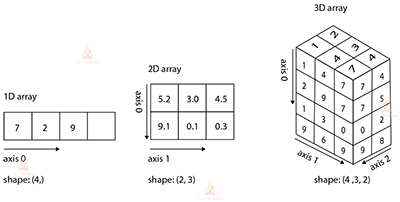

In [22]:
import numpy as np

# Simulating 5 samples of single-feature input tracking tracking data
raw_list = [1.2, 2.4, 3.1, 4.0, 5.3]
vector_1d = np.array(raw_list)

print("--- 1. Base NumPy Vector properties ---")
print("Data Vector:", vector_1d)
print("Shape:", vector_1d.shape)        # Yields (5,) -> Flat 1D line matrix
print("Dimensions:", vector_1d.ndim)    # Yields 1

# ERROR TRAP DEMONSTRATION:
# Passing this 1D vector directly into an sklearn model estimator will raise an error:
# "Expected 2D array, got 1D array instead"

print("\n--- 2. Reshaping into 2D Feature Columns --- ")
# Reshape syntax (-1 means 'compute this dimension automatically', 1 means 'force 1 column format')
matrix_2d = vector_1d.reshape(-1, 1)

print("Reshaped Matrix Output:\n", matrix_2d)
print("New Shape:", matrix_2d.shape)    # Yields (5, 1) -> 5 rows, 1 feature column (Valid for X)
print("New Dimensions:", matrix_2d.ndim) # Yields 2

--- 1. Base NumPy Vector properties ---
Data Vector: [1.2 2.4 3.1 4.  5.3]
Shape: (5,)
Dimensions: 1

--- 2. Reshaping into 2D Feature Columns --- 
Reshaped Matrix Output:
 [[1.2]
 [2.4]
 [3.1]
 [4. ]
 [5.3]]
New Shape: (5, 1)
New Dimensions: 2


---
## L. Data Integrity: Train / Test Splitting Architecture

* To evaluate machine learning models objectively, we never test a model using the exact same metrics it looked at during training.

* This violates data integrity principles and hides overfitting issues.

* We must segment data into independent training and testing sets before starting model evaluations.

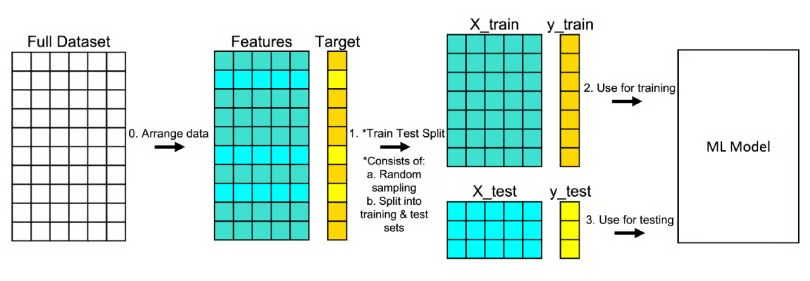

In [23]:
import numpy as np

# Simulating a mock dataset with 10 records
# X matrix (10 structural samples, 2 feature columns each)
X = np.arange(20).reshape(10, 2)
# y labels (10 evaluation classes matching each record sequence)
y = np.arange(10) # Fixed: Initialized y with 10 elements

print("--- 1. Full Dataset Configurations ---")
print("Full Feature Matrix Shape X:", X.shape)
print("Full Target Vector Shape y:", y.shape)

print("\n--- 2. Simulating a Standard 80/20 Train-Test Segment Split ---")
# Outlining slice bounds
split_index = int(0.8 * len(X))  # Evaluates to index row 8

# Slicing operations executing distinct isolation tasks
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training Feature Block (X_train) Rows: {len(X_train)} | Shape: {X_train.shape}")
print(f"Testing Feature Block (X_test) Rows: {len(X_test)} | Shape: {X_test.shape}")
print(f"Training Label Targets (y_train) Values: {y_train}")
print(f"Testing Label Targets (y_test) Values: {y_test}")

# Note: In actual assignments, we will automate this sequence using Scikit-Learn's built-in
# `train_test_split(X, y)` function, which randomizes and shuffles the records safely.

--- 1. Full Dataset Configurations ---
Full Feature Matrix Shape X: (10, 2)
Full Target Vector Shape y: (10,)

--- 2. Simulating a Standard 80/20 Train-Test Segment Split ---
Training Feature Block (X_train) Rows: 8 | Shape: (8, 2)
Testing Feature Block (X_test) Rows: 2 | Shape: (2, 2)
Training Label Targets (y_train) Values: [0 1 2 3 4 5 6 7]
Testing Label Targets (y_test) Values: [8 9]


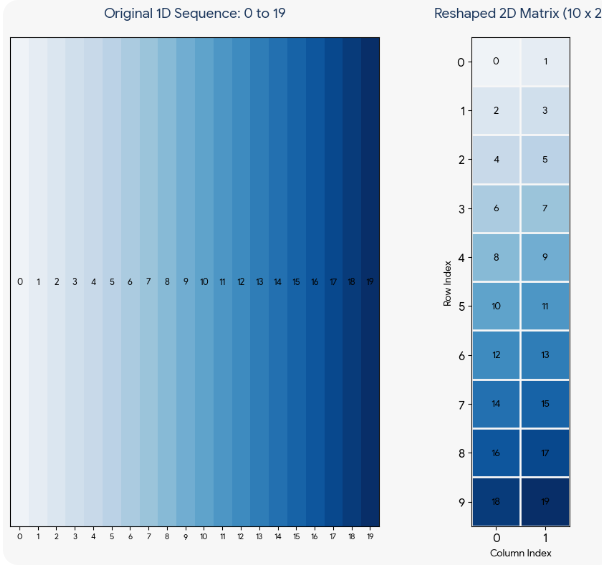